# ***Customer Churn Analysis Prediction***

## Summary
Business problem:
Telecom companies lose revenue every time a customer cancels
service ("churns"). Acquiring a new customer typically costs more than retaining an
existing one, so predicting *which* customers are likely to leave lets the business
target them with retention offers before they go.



Approach:
This analysis explores the Telco Customer dataset (7,043 customers) to
identify the strongest patterns behind churn, then builds a Random Forest model to
predict it.


Key result:
Our model achieves 79% accuracy and correctly identifies 49% of customers who
actually churn (recall), with 62% precision on those flagged. The strongest
predictors are contract type, tenure, and payment method — confirmed both by
the churn-rate charts above and the model itself.



## Loading the Dataset

In [4]:

import numpy as np
import pandas as pd

dataset= pd.read_csv('/Telco-Customer-Churn (1)(in).csv')
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Key Metrics

In [5]:
total_customers = len(dataset)
churn_rate = (dataset['Churn'] == 'Yes').mean() * 100
avg_monthly = dataset['MonthlyCharges'].mean()
avg_tenure = dataset['tenure'].mean()

print(f"Total customers: {total_customers:,}")
print(f"Churn rate: {churn_rate:.1f}%")
print(f"Average monthly charge: ${avg_monthly:.2f}")
print(f"Average tenure: {avg_tenure:.1f} months")

Total customers: 7,043
Churn rate: 26.5%
Average monthly charge: $64.76
Average tenure: 32.4 months


## Understanding the Dataset

In [6]:
print(dataset.isnull().sum())
print(dataset.describe())



customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


#

## Analyzing Churn Distribution



##

Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_1652/2545296422.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=dataset, palette='coolwarm')


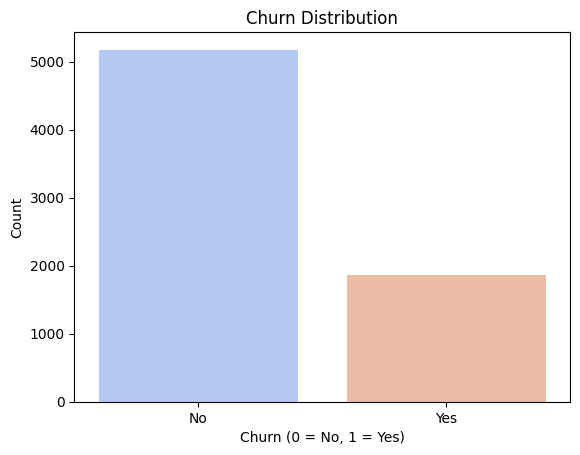

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

print(dataset['Churn'].value_counts())
sns.countplot(x='Churn', data=dataset, palette='coolwarm')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Insight:
about 26.5% of customers in this dataset churned — a meaningful minority,
not a rare event. This imbalance matters later: a model that *always* predicts "no
churn" would already be ~73% accurate while catching zero actual churners, so accuracy
alone won't tell us if the model is any good.

In [8]:
churn_numeric = (dataset['Churn'] == 'Yes').astype(int)

/tmp/ipykernel_1652/4046058148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset['Contract'], y=churn_numeric, palette='coolwarm', errorbar=None)


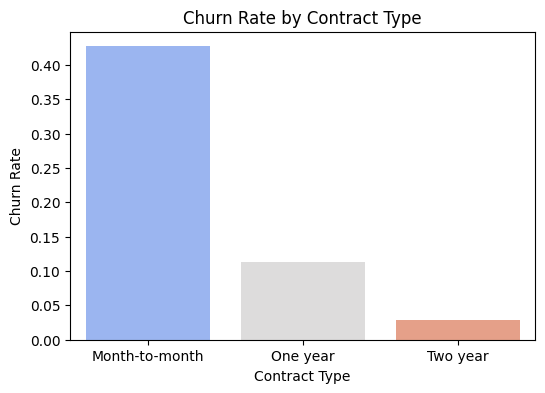

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(x=dataset['Contract'], y=churn_numeric, palette='coolwarm', errorbar=None)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.show()

Insight:
contract type is the single biggest factor. Month-to-month customers
churn at roughly **43%**, versus **11%** for one-year contracts and just **3%** for
two-year contracts. Getting customers onto longer contracts is likely the highest-
leverage retention lever available.

/tmp/ipykernel_1652/2585193089.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_groups, y=churn_numeric, palette='coolwarm', errorbar=None)


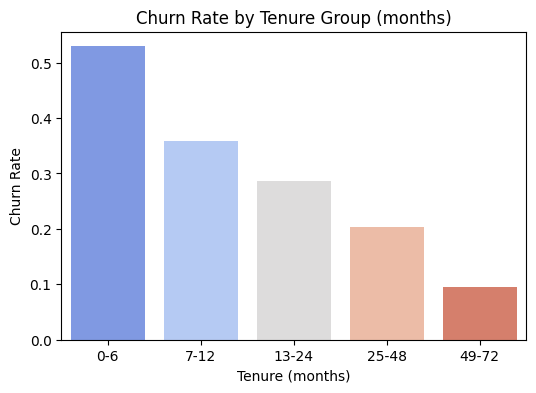

In [10]:
tenure_groups = pd.cut(dataset['tenure'], bins=[-1, 6, 12, 24, 48, 72],
                        labels=['0-6', '7-12', '13-24', '25-48', '49-72'])
plt.figure(figsize=(6,4))
sns.barplot(x=tenure_groups, y=churn_numeric, palette='coolwarm', errorbar=None)
plt.title('Churn Rate by Tenure Group (months)')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate')
plt.show()

Insight:
the first 6 months are the highest-risk period — churn rate is roughly
**53%** for brand-new customers, falling steadily to about **9-10%** for customers
past their 4th year. Retention efforts aimed at new customers likely have the biggest
payoff.

/tmp/ipykernel_1652/3611679251.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset['PaymentMethod'], y=churn_numeric, palette='coolwarm', errorbar=None)


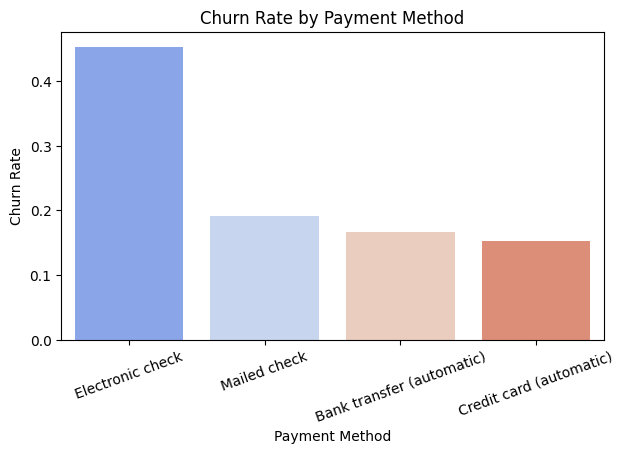

In [11]:
plt.figure(figsize=(7,4))
sns.barplot(x=dataset['PaymentMethod'], y=churn_numeric, palette='coolwarm', errorbar=None)
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.show()

**Insight:**
 customers paying by electronic check churn at about **45%**, roughly
double every other payment method (15-19%). Automatic payment methods correlate with
much stickier customers — worth investigating whether this is about payment friction,
or just correlated with the type of customer who sets up autopay in the first place.

## Data Preprocessing

In [12]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'].fillna(0, inplace=True)

/tmp/ipykernel_1652/3981023929.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['TotalCharges'].fillna(0, inplace=True)


## Handling Categorical Variables

In [13]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for col in categorical_cols:
    dataset[col] = labelencoder.fit_transform(dataset[col])

## Feature Selection and Splitting Data


In [14]:
from sklearn.model_selection import train_test_split

X = dataset.drop(['customerID', 'Churn'], axis=1)
y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Feature Scalling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

## Model Evaluation


In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.79


**Why accuracy alone is misleading here:** only ~26.5% of customers churn, so a model
that predicts "no churn" for everyone would already score ~73% accuracy while being
completely useless. The numbers below tell the real story:
- **Precision** — of the customers we flagged as "will churn," what % actually did?
- **Recall** — of the customers who actually churned, what % did we catch?

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1041
       Churn       0.62      0.49      0.55       368

    accuracy                           0.79      1409
   macro avg       0.72      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## Confusion Matrix and Performance Metrics


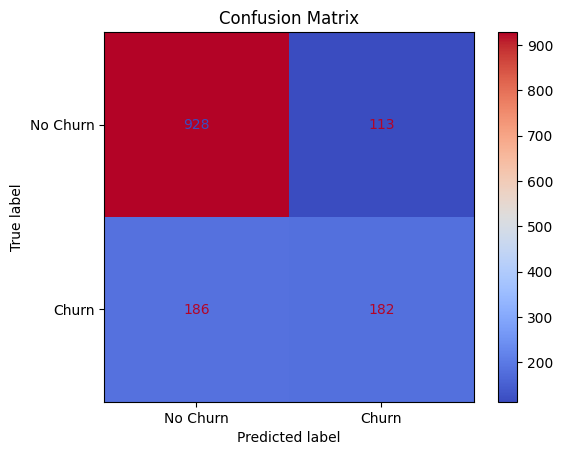

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="coolwarm")
plt.title('Confusion Matrix')
plt.show()

## What Drives Churn? (Feature Importance)

/tmp/ipykernel_1652/3379715526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='coolwarm')


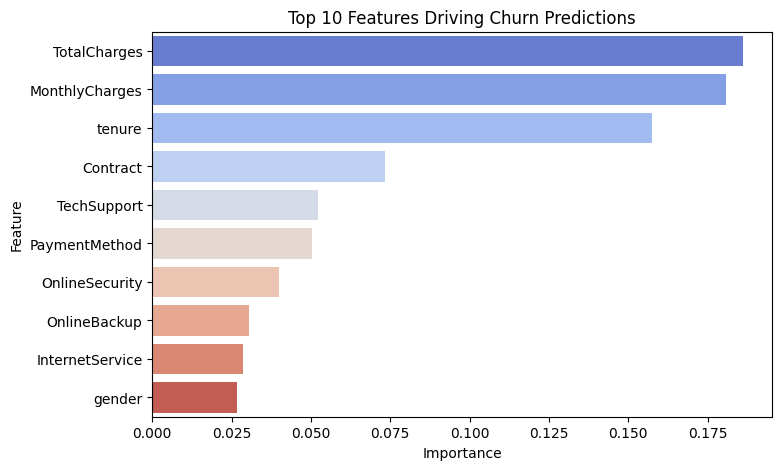

TotalCharges       0.186048
MonthlyCharges     0.180671
tenure             0.157382
Contract           0.073387
TechSupport        0.052068
PaymentMethod      0.050436
OnlineSecurity     0.040063
OnlineBackup       0.030400
InternetService    0.028667
gender             0.026814
dtype: float64


In [21]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='coolwarm')
plt.title('Top 10 Features Driving Churn Predictions')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print(importances)

## Recommendations

Based on the analysis above:
1. **Incentivize longer contracts** — churn drops from 43% (month-to-month) to 3%
   (two-year). Even a modest discount for switching is likely worth it.
2. **Focus retention efforts in the first 6 months** — this is where churn risk peaks.
3. **Investigate electronic check as a payment friction point**, or migrate these
   customers toward autopay.
4. **Use this model's predictions** to proactively flag at-risk customers for a
   retention team, rather than waiting for them to cancel.